# grid resolutions / testing nearest neighbor

In [10]:
import matplotlib.pyplot as plt
import xarray as xr 
import numpy as np
from scipy.spatial import cKDTree

hfo_grib2 = "hfo_nwps_CG4_20251114_1200.grib2"
sew_grib2 = "sew_nwps_CG1_20251117_0000.grib2"

hfo_fc = xr.open_dataset(hfo_grib2, engine="cfgrib", filter_by_keys={"dataType": "fc"}, backend_kwargs={"indexpath": ""}) 
hfo_an = xr.open_dataset(hfo_grib2, engine="cfgrib", filter_by_keys={"dataType": "an"}, backend_kwargs={"indexpath": ""}) 
sew_fc = xr.open_dataset(sew_grib2, engine="cfgrib", filter_by_keys={"dataType": "fc"}, backend_kwargs={"indexpath": ""})

fcs = {"hfo": hfo_fc, "sew": sew_fc}

In [11]:
for wfo, fc in fcs.items():
    lat_spacing = fc.latitude.diff("latitude").mean().values 
    lon_spacing = fc.longitude.diff("longitude").mean().values  
    
    center_lat = fc.latitude.mean().values 
    
    # 1 degree lat ~ 111km everywhere 
    lat_resolution = lat_spacing * 111000 
    
    # 1 degree lon varies with latitude ~ 111km * cos(latitude). NWPS says their models range 1.8km - 500m, but this is almost 4km.. for Seattle. hm
    lon_resolution = lon_spacing * 111000 * np.cos(np.radians(center_lat))
    print(f"dataset: {wfo}")
    print(f"lat spacing: {lat_spacing:.6f}°")
    print(f"long spacing: {lon_spacing:.6f}°")
    print(f"cell res (lat): ~{lat_resolution:.0f} m")
    print(f"cell res (lon): ~{lon_resolution:.0f} m")
    print(f"approx. cell size: {lat_resolution:.0f}m x {lon_resolution:.0f}m")

dataset: hfo
lat spacing: 0.004505°
long spacing: 0.004808°
cell res (lat): ~500 m
cell res (lon): ~499 m
approx. cell size: 500m x 499m
dataset: sew
lat spacing: 0.036087°
long spacing: 0.051939°
cell res (lat): ~4006 m
cell res (lon): ~3876 m
approx. cell size: 4006m x 3876m


## test spot extraction with nearest neighbor selection

In [12]:
## geo.py code 
from typing import Literal 

EPSILON = 1e-9  # small fault tolerance for floating point errors
LAT_MIN = -90.0
LAT_MAX = 90.0
LON_SIGNED_MIN = -180.0
LON_SIGNED_MAX = 180.0
LON_UNSIGNED_MIN = 0.0
LON_UNSIGNED_MAX = 360.0

def valid_longitude(
    longitude: float, range_type: Literal["signed", "unsigned"]
) -> bool:
    if range_type == "signed":
        return (LON_SIGNED_MIN - EPSILON) <= longitude <= (LON_SIGNED_MAX + EPSILON)
    return (LON_UNSIGNED_MIN - EPSILON) <= longitude <= (LON_UNSIGNED_MAX + EPSILON)


def longitude_to_360(longitude: float, precision: int = 6) -> float:
    if not valid_longitude(longitude, range_type="signed"):
        raise ValueError(f"Longitude must be in range [-180, 180], got {longitude}") 
    return round(longitude % 360, precision) 

# mock db return 
surf_spots = [
    # Hookipa, Dumps 

    # HOOKIPA
    # 20.934244°N 156.359621°W 

    # DUMPS 
    # 20.612921°N 156.438039°W or 203.561961  

    # OFFSHORE North east to test currents data
    # 20.9406666667, -156.0708333333
    {
        "id": 1, 
        "latitude": 20.9342,
        "longitude": -156.3596,
    }, 
    {
        "id": 2, 
        "latitude": 20.6129,
        "longitude": -156.4380,
    },   
    {
        "id": 3, 
        "latitude": 20.9410,
        "longitude": -156.0708,
    },     
        
]

# actual data setup
surf_spot_ids = np.array([surf_spot["id"] for surf_spot in surf_spots])
surf_spot_lats = np.array([surf_spot["latitude"] for surf_spot in surf_spots])
surf_spot_lons = np.array([longitude_to_360(surf_spot["longitude"]) for surf_spot in surf_spots])


In [13]:
hfo_an_data = hfo_an.sel(
        latitude=xr.DataArray(surf_spot_lats, dims="surf_spot"),
        longitude=xr.DataArray(surf_spot_lons, dims="surf_spot"),
        method="nearest"
    ).assign_coords(
        surf_spot_id=("surf_spot", surf_spot_ids),
        surf_spot_lat=("surf_spot", surf_spot_lats),
        surf_spot_lon=("surf_spot", surf_spot_lons)
    ).rename(
        {"latitude": "selected_lat", "longitude": "selected_lon", "time": "analysis_time"}
    )

hfo_fc_data = hfo_fc.sel(
        latitude=xr.DataArray(surf_spot_lats, dims="surf_spot"),
        longitude=xr.DataArray(surf_spot_lons, dims="surf_spot"),
        method="nearest"
    ).assign_coords(
        surf_spot_id=("surf_spot", surf_spot_ids),
        surf_spot_lat=("surf_spot", surf_spot_lats),
        surf_spot_lon=("surf_spot", surf_spot_lons)
    ).rename(
        {"latitude": "selected_lat", "longitude": "selected_lon", "time": "analysis_time"}
    ).swap_dims(
        {"step": "valid_time"}
    )

hfo_fc_data

<xarray.Dataset> Size: 18kB
Dimensions:        (valid_time: 144, surf_spot: 3)
Coordinates:
  * valid_time     (valid_time) datetime64[ns] 1kB 2025-11-14T13:00:00 ... 20...
    analysis_time  datetime64[ns] 8B ...
    step           (valid_time) timedelta64[ns] 1kB 01:00:00 ... 6 days 00:00:00
    surface        float64 8B ...
    selected_lat   (surf_spot) float64 24B 20.94 20.61 20.94
    selected_lon   (surf_spot) float64 24B 203.6 203.6 203.9
    surf_spot_id   (surf_spot) int64 24B 1 2 3
    surf_spot_lat  (surf_spot) float64 24B 20.93 20.61 20.94
    surf_spot_lon  (surf_spot) float64 24B 203.6 203.6 203.9
Dimensions without coordinates: surf_spot
Data variables:
    swh            (valid_time, surf_spot) float32 2kB ...
    dirpw          (valid_time, surf_spot) float32 2kB ...
    perpw          (valid_time, surf_spot) float32 2kB ...
    shts           (valid_time, surf_spot) float32 2kB ...
    wdir           (valid_time, surf_spot) float32 2kB ...
    ws             (valid_time, surf_spot) float32 2kB ...
    zos            (valid_time, surf_spot) float32 2kB ...
    dirc           (valid_time, surf_spot) float32 2kB ...
    spc            (valid_time, surf_spot) float32 2kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2025-11-26T11:38 GRIB to CDM+CF via cfgrib-0.9.1...

In [14]:
print("spots: ")
for i, spot in enumerate(surf_spots):
  print(f"  {spot['id']}: lat={surf_spot_lats[i]}, lon={surf_spot_lons[i]}")

print("actual grid points selected:")
print(f"  selected_lat: {hfo_fc_data.selected_lat.values}")
print(f"  selected_lon: {hfo_fc_data.selected_lon.values}") 

print("\nchecking original hfo_an data:")
for i in range(len(surf_spots)):
  selected_lat = hfo_fc_data.selected_lat.values[i]
  selected_lon = hfo_fc_data.selected_lon.values[i]
  point_data = hfo_fc.sel(latitude=selected_lat, longitude=selected_lon, method="nearest")
  print(f"  point {i+1} (lat={selected_lat}, lon={selected_lon})\nswh={point_data.swh.values}")

print(f"\ngrid bounds:")
print(f"  lat: {hfo_fc.latitude.min().values} to {hfo_fc.latitude.max().values}")
print(f"  lon: {hfo_fc.longitude.min().values} to {hfo_fc.longitude.max().values}") 

hf_fs = hfo_fc_data
hf_an = hfo_an_data

spots: 
  1: lat=20.9342, lon=203.6404
  2: lat=20.6129, lon=203.562
  3: lat=20.941, lon=203.9292
actual grid points selected:
  selected_lat: [20.936078 20.611718 20.940583]
  selected_lon: [203.63846122 203.56153821 203.92692249]

checking original hfo_an data:
  point 1 (lat=20.936078000000148, lon=203.6384612165598)
swh=[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  point 2 (lat=20.61171800000002, lon=203.56153821019052)
swh=[nan nan nan nan nan nan n

valid ocean points: 9143 / 17222 (53.1%)


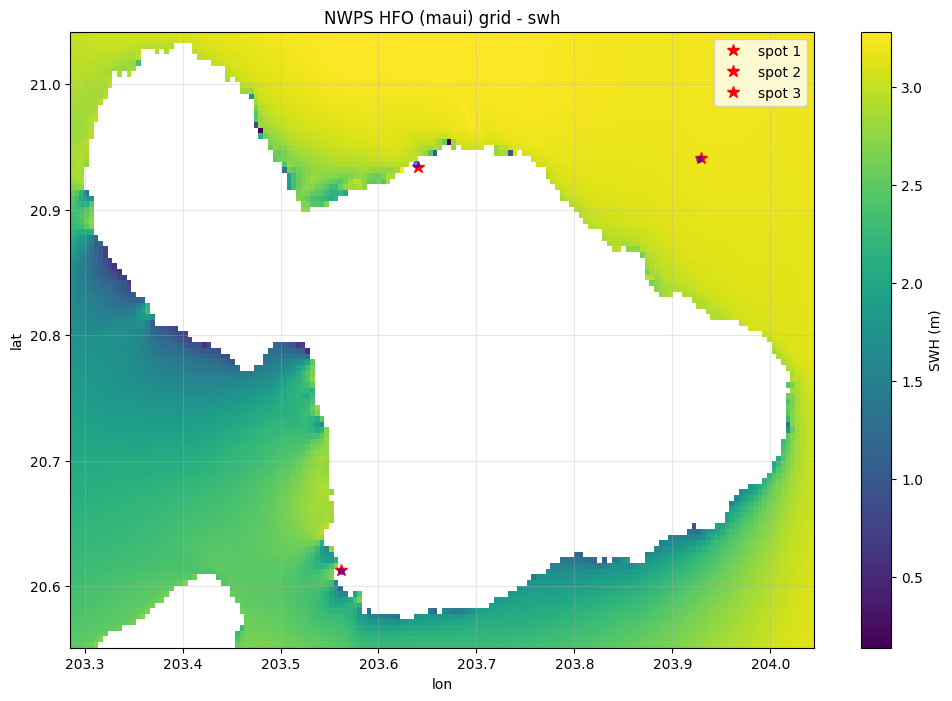


spot locations vs selected grid points:
spot 1: NaN
spot 2: NaN
spot 3: VALID


In [15]:
fc_sample = hfo_fc.isel(step=0)

valid_mask = ~np.isnan(fc_sample.swh.values)
print(f"valid ocean points: {valid_mask.sum()} / {valid_mask.size} ({valid_mask.sum()/valid_mask.size*100:.1f}%)")

plt.figure(figsize=(12, 8))
plt.pcolormesh(hfo_fc.longitude, hfo_fc.latitude, fc_sample.swh.values, shading='auto')
plt.colorbar(label='SWH (m)')

for i, spot in enumerate(surf_spots):
    # plot surf spot
    plt.plot(surf_spot_lons[i], surf_spot_lats[i], 'r*', markersize=9,
           label=f"spot {spot['id']}")
    # plot the actual selected grid point
    plt.plot(hfo_an_data.selected_lon.values[i], hfo_an_data.selected_lat.values[i],
           'bo', markersize=4, alpha=0.5)

plt.xlabel('lon')
plt.ylabel('lat')
plt.title('NWPS HFO (maui) grid - swh')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nspot locations vs selected grid points:")
for i, spot in enumerate(surf_spots):
  swh_val = fc_sample.sel(
      latitude=surf_spot_lats[i],
      longitude=surf_spot_lons[i],
      method="nearest"
  ).swh.values
  print(f"spot {spot['id']}: {'VALID' if not np.isnan(swh_val) else 'NaN'}")

# notes on nearest neighbor for x-array 

seems like this is a common issue within x-array's nearest neighbor processing, 
such that if 2D DataSets include a large amount of NAN values, there is no way 
to enforce the nearest-neighbor functionality in x-array to ignore NAN data variable
values, as the sel method is meant for indices/coordinates, and does not concern itself 
with the actual data dar values. the common solution/ suggestion is to create 
a custom nearest neighbor function that only selects values that are not NAN within some kind of radius. 

another suggestion is to use interpolation. doesn't make sense in this application though,
since we don't want to be creating "ghost" spots or blending forecasting data into land cells. 
custom nearest neighbor seems like the best approach.  

kdTree w/ scipy is probbaly the best or future scale w/ log(n) run time 

### kdtree build 
build O(mlog(m))
+ 
query O(nlog(m)) 
n = # of surf spots. 
m = # of valid grid points

VS

### haversine loop  
query O(n * m) 
n = # of points in search radius


[x-array gh issue thread](https://github.com/pydata/xarray/issues/644)

In [16]:
def build_ocean_kdtree(ds, var="swh"): 
    # creates valid mask by checking if swh is NAN, 
    # 1 var mask is better than checking 9 data vars
    # and honestly if model run fails for a point, fine to 
    # have the mask like this. 
    valid_mask = ~ds[var].isel(step=0).isnull() 

    # get all lat/long grid points, extract only valid ocean points
    lat_grid, lon_grid = np.meshgrid(ds.latitude, ds.longitude, indexing="ij") 
    ocean_lats = lat_grid[valid_mask.values] 
    ocean_lons = lon_grid[valid_mask.values]

    # convert to radians for haversine 
    ocean_coords_rad = np.column_stack([
        np.radians(ocean_lats), 
        np.radians(ocean_lons)
    ]) 

    # build kd-tree
    tree = cKDTree(ocean_coords_rad)

    return tree, ocean_lats, ocean_lons

def query_nearest_ocean_points(tree, ocean_lats, ocean_longs, target_lats, target_lons): 
    target_coords_rad = np.column_stack([
        np.radians(target_lats), 
        np.radians(target_lons)
    ]) 

    # query for distances and their indices 
    distances, indicies = tree.query(target_coords_rad) 

    # get selected coords 
    selected_lats = ocean_lats[indicies] 
    selected_lons = ocean_lons[indicies] 
    distances_km = distances * 6371

    return selected_lats, selected_lons, distances_km 

In [17]:
# use kdtree w/ haversine to get nearest ocean lats and lons

tree, ocean_lats, ocean_lons = build_ocean_kdtree(hfo_fc, "swh") 

selected_lats, selected_lons, distances = query_nearest_ocean_points(tree, ocean_lats, ocean_lons, surf_spot_lats, surf_spot_lons)

hfo_fc_ocean = hfo_fc.sel(
        latitude=xr.DataArray(selected_lats, dims="surf_spot"),
        longitude=xr.DataArray(selected_lons, dims="surf_spot"),
    ).assign_coords(
        surf_spot_id=("surf_spot", surf_spot_ids),
        surf_spot_lat=("surf_spot", surf_spot_lats),
        surf_spot_lon=("surf_spot", surf_spot_lons)
    ).rename(
        {"latitude": "selected_lat", "longitude": "selected_lon", "time": "analysis_time"}
    ).swap_dims(
        {"step": "valid_time"}
    ) 

print("spots: ")
for i, spot in enumerate(surf_spots):
  print(f"  {spot['id']}: lat={surf_spot_lats[i]}, lon={surf_spot_lons[i]}")

print("actual grid points selected:")
print(f"  selected_lat: {hfo_fc_ocean.selected_lat.values}")
print(f"  selected_lon: {hfo_fc_ocean.selected_lon.values}") 

print("\nchecking original hfo_an data:")
for i in range(len(surf_spots)):
  selected_lat = hfo_fc_ocean.selected_lat.values[i]
  selected_lon = hfo_fc_ocean.selected_lon.values[i]
  point_data = hfo_fc.sel(latitude=selected_lat, longitude=selected_lon, method="nearest")
  print(f"  point {i+1} (lat={selected_lat}, lon={selected_lon})\nswh={point_data.swh.values}\ndirc={point_data.dirc.values}\nspc={point_data.spc.values}")

print(f"\ngrid bounds:")
print(f"  lat: {hfo_fc.latitude.min().values} to {hfo_fc.latitude.max().values}")
print(f"  lon: {hfo_fc.longitude.min().values} to {hfo_fc.longitude.max().values}") 

spots: 
  1: lat=20.9342, lon=203.6404
  2: lat=20.6129, lon=203.562
  3: lat=20.941, lon=203.9292
actual grid points selected:
  selected_lat: [20.940583 20.616223 20.940583]
  selected_lon: [203.63846122 203.55673052 203.92692249]

checking original hfo_an data:
  point 1 (lat=20.94058300000015, lon=203.6384612165598)
swh=[3.0011811 2.9856312 2.9711425 2.957286  2.9438856 2.9306035 2.9277174
 2.9290915 2.9177265 2.8962557 2.8659163 2.830027  2.792254  2.7555125
 2.71566   2.6767187 2.6353137 2.6012497 2.5774634 2.5641584 2.5491972
 2.5177839 2.4837666 2.4536438 2.4230425 2.389053  2.3498504 2.3110323
 2.274898  2.2398822 2.2139578 2.1845052 2.1697345 2.1533127 2.1341143
 2.1172767 2.0907228 2.0566375 2.0282314 2.0062377 1.9931172 1.9867649
 1.9824165 1.9730943 1.9535863 1.9244661 1.8984494 1.876296  1.8612207
 1.8513412 1.8442739 1.8360324 1.8283106 1.820489  1.8147066 1.8083609
 1.8023981 1.80169   1.8032277 1.7957112 1.7957044 1.8055941 1.8473936
 1.8918517 1.9182705 1.9349939 1.93

### visualize w/ new nearest neighbor 

spot_id: 1
   lat: 20.9342, lon: 203.6404
   selected_lat: 20.94058300000015, selected_lon: 203.6384612165598
spot_id: 2
   lat: 21.0176, lon: 203.359
   selected_lat: 21.01716800000018, selected_lon: 203.3548076305731
spot_id: 3
   lat: 20.612921, lon: 203.561961
   selected_lat: 20.616223000000023, selected_lon: 203.55673052229244


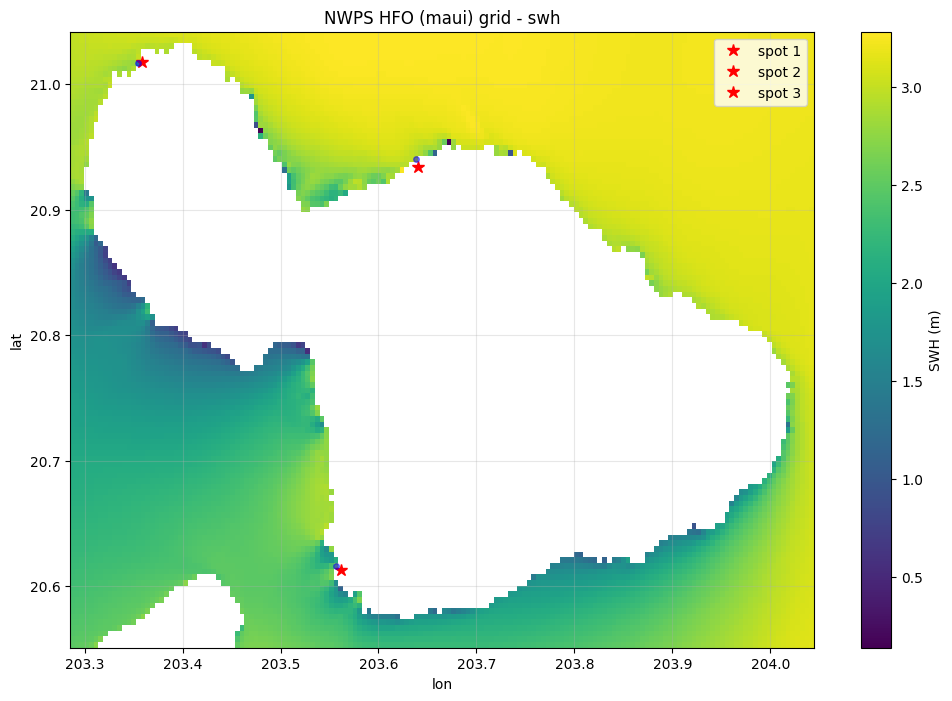

In [137]:
fc_sample = hfo_fc.isel(step=0)

plt.figure(figsize=(12, 8))
plt.pcolormesh(hfo_fc.longitude, hfo_fc.latitude, fc_sample.swh.values, shading='auto')
plt.colorbar(label='SWH (m)')

for i, spot in enumerate(surf_spots):
    # plot surf spot
    plt.plot(surf_spot_lons[i], surf_spot_lats[i], 'r*', markersize=9,
           label=f"spot {spot['id']}")
    # plot the actual selected grid point
    plt.plot(hfo_fc_ocean.selected_lon.values[i], hfo_fc_ocean.selected_lat.values[i],
           'bo', markersize=4, alpha=0.5)
    
    print(f"spot_id: {surf_spot_ids[i]}")
    print(f"   lat: {surf_spot_lats[i]}, lon: {surf_spot_lons[i]}")
    print(f"   selected_lat: {hfo_fc_ocean.selected_lat.values[i]}, selected_lon: {hfo_fc_ocean.selected_lon.values[i]}")

plt.xlabel('lon')
plt.ylabel('lat')
plt.title('NWPS HFO (maui) grid - swh')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### works! yippe